In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SWPS: ALGORYTM GENETYCZNY DLA FUNKCJI POSZARPANEJ / WIELOMODALNEJ
# ============================================================
# Cel:
#   Zminimalizować funkcję 2D, która ma wiele minimów lokalnych,
#   jest "poszarpana" i trudna dla prostych metod lokalnych.
#
# Funkcja została specjalnie zbudowana tak, aby zawierała:
#   - składnik kwadratowy,
#   - oscylacje sinus/cosinus,
#   - dodatkowe zaburzenia lokalne.
#
# Dzięki temu dobrze pokazuje sens użycia algorytmów ewolucyjnych.
# ============================================================

In [2]:
# -----------------------------
# PARAMETRY PROBLEMU I ALGORYTMU
# -----------------------------
BOUNDS = [(-6.0, 6.0), (-6.0, 6.0)]  # zakres przeszukiwania dla x i y
POP_SIZE = 80
GENERATIONS = 120
ELITE_SIZE = 6
TOURNAMENT_SIZE = 4
CROSSOVER_RATE = 0.9
MUTATION_RATE = 0.25
MUTATION_STD = 0.35
SEED = 42

rng = np.random.default_rng(SEED)



In [3]:
# -----------------------------
# FUNKCJA CELU: WIELE MINIMÓW LOKALNYCH
# -----------------------------
def rugged_function(x, y):
    """
    Poszarpana funkcja 2D z wieloma minimami lokalnymi.

    Składniki:
    1. Lekka paraboloida           -> daje ogólny kształt globalny
    2. Sinus/cosinus               -> tworzy fale i lokalne minima
    3. Sprzężenie x*y              -> dodatkowa nieregularność
    4. Lokalna dolina gaussowska   -> silniejszy lej minimum globalnego
    """
    base = 0.12 * (x**2 + y**2)
    waves = 1.6 * np.sin(3.2 * x) * np.cos(2.7 * y)
    ripples = 0.7 * np.sin(5.5 * x + 0.5 * y) + 0.6 * np.cos(4.7 * y - 0.3 * x)
    interaction = 0.18 * np.sin(x * y)
    valley = -3.8 * np.exp(-((x - 1.7)**2 + (y + 2.2)**2) / 0.9)
    return base + waves + ripples + interaction + valley


def objective(individual):
    x, y = individual
    return rugged_function(x, y)


In [4]:
# -----------------------------
# INICJALIZACJA POPULACJI
# -----------------------------
def random_individual(bounds):
    return np.array([
        rng.uniform(low, high) for (low, high) in bounds
    ], dtype=float)


def initialize_population(pop_size, bounds):
    return [random_individual(bounds) for _ in range(pop_size)]

In [5]:
# -----------------------------
# OCENA FITNESS
# -----------------------------
def evaluate_population(population):
    scores = np.array([objective(ind) for ind in population], dtype=float)
    return scores

In [6]:
# -----------------------------
# SELEKCJA TURNIEJOWA
# -----------------------------
def tournament_selection(population, scores, tournament_size=3):
    indices = rng.choice(len(population), size=tournament_size, replace=False)
    best_idx = indices[np.argmin(scores[indices])]  # minimalizacja
    return population[best_idx].copy()


In [7]:
# -----------------------------
# KRZYŻOWANIE ARYTMETYCZNE
# -----------------------------
def crossover(parent1, parent2):
    if rng.random() > CROSSOVER_RATE:
        return parent1.copy(), parent2.copy()

    alpha = rng.random()
    child1 = alpha * parent1 + (1 - alpha) * parent2
    child2 = alpha * parent2 + (1 - alpha) * parent1
    return child1, child2


In [8]:
# -----------------------------
# MUTACJA GAUSSOWSKA
# -----------------------------
def mutate(individual, bounds):
    child = individual.copy()
    for i, (low, high) in enumerate(bounds):
        if rng.random() < MUTATION_RATE:
            child[i] += rng.normal(0.0, MUTATION_STD)
            child[i] = np.clip(child[i], low, high)
    return child



In [9]:
# -----------------------------
# ELITYZM
# -----------------------------
def get_elites(population, scores, elite_size):
    elite_indices = np.argsort(scores)[:elite_size]
    return [population[i].copy() for i in elite_indices]



In [10]:
# -----------------------------
# GŁÓWNA PĘTLA ALGORYTMU GENETYCZNEGO
# -----------------------------
def genetic_algorithm():
    population = initialize_population(POP_SIZE, BOUNDS)
    best_history = []
    mean_history = []
    best_points = []

    best_solution = None
    best_score = np.inf

    for generation in range(GENERATIONS):
        scores = evaluate_population(population)

        gen_best_idx = np.argmin(scores)
        gen_best_solution = population[gen_best_idx].copy()
        gen_best_score = scores[gen_best_idx]

        if gen_best_score < best_score:
            best_score = gen_best_score
            best_solution = gen_best_solution.copy()

        best_history.append(best_score)
        mean_history.append(np.mean(scores))
        best_points.append(best_solution.copy())

        elites = get_elites(population, scores, ELITE_SIZE)
        new_population = elites.copy()

        while len(new_population) < POP_SIZE:
            p1 = tournament_selection(population, scores, TOURNAMENT_SIZE)
            p2 = tournament_selection(population, scores, TOURNAMENT_SIZE)

            c1, c2 = crossover(p1, p2)
            c1 = mutate(c1, BOUNDS)
            c2 = mutate(c2, BOUNDS)

            new_population.append(c1)
            if len(new_population) < POP_SIZE:
                new_population.append(c2)

        population = new_population

    return best_solution, best_score, np.array(best_history), np.array(mean_history), np.array(best_points)



In [11]:
# -----------------------------
# WIZUALIZACJA FUNKCJI I WYNIKU
# -----------------------------
def plot_results(best_solution, best_score, best_history, mean_history, best_points):
    x = np.linspace(BOUNDS[0][0], BOUNDS[0][1], 300)
    y = np.linspace(BOUNDS[1][0], BOUNDS[1][1], 300)
    X, Y = np.meshgrid(x, y)
    Z = rugged_function(X, Y)

    plt.figure(figsize=(10, 8))
    contour = plt.contourf(X, Y, Z, levels=60)
    plt.colorbar(contour, label='wartość funkcji')

    plt.plot(best_points[:, 0], best_points[:, 1], 'w.-', linewidth=1.5, markersize=4, label='trajektoria najlepszego')
    plt.scatter(best_solution[0], best_solution[1], s=160, marker='*', label='najlepsze rozwiązanie')

    plt.title('Algorytm genetyczny: minimum funkcji poszarpanej')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(best_history, label='najlepszy wynik globalny')
    plt.plot(mean_history, label='średni wynik populacji')
    plt.title('Postęp optymalizacji w kolejnych generacjach')
    plt.xlabel('Generacja')
    plt.ylabel('Wartość funkcji')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Najlepsze znalezione rozwiązanie:
x = 1.324520
y = -2.118191
wartość funkcji = -4.138268


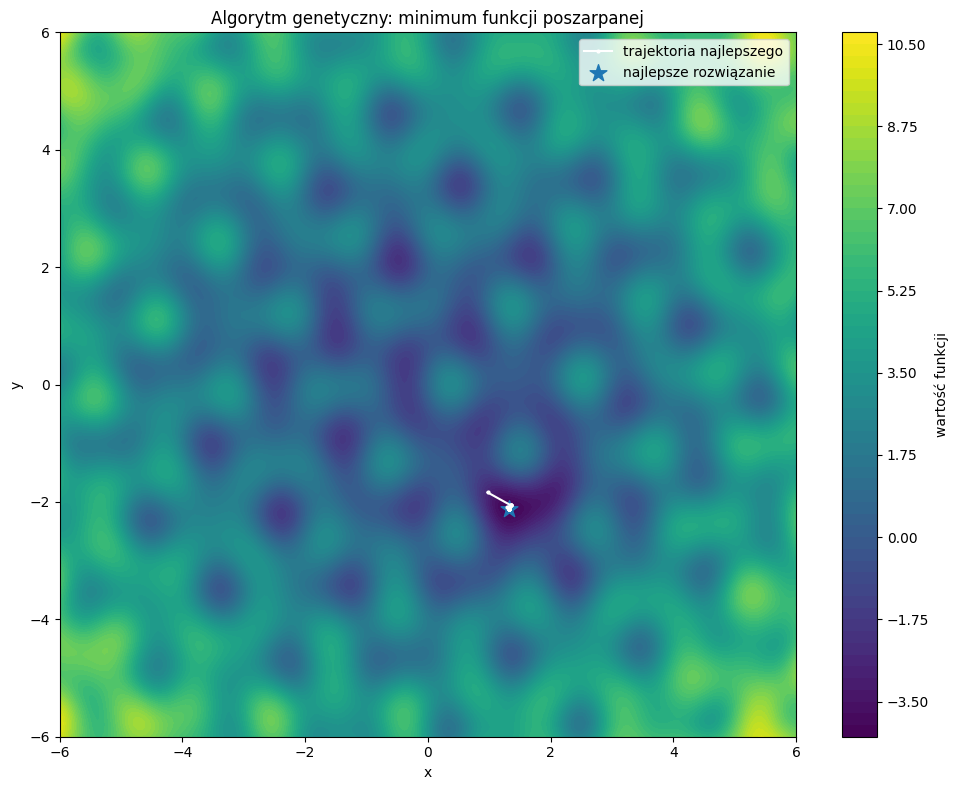

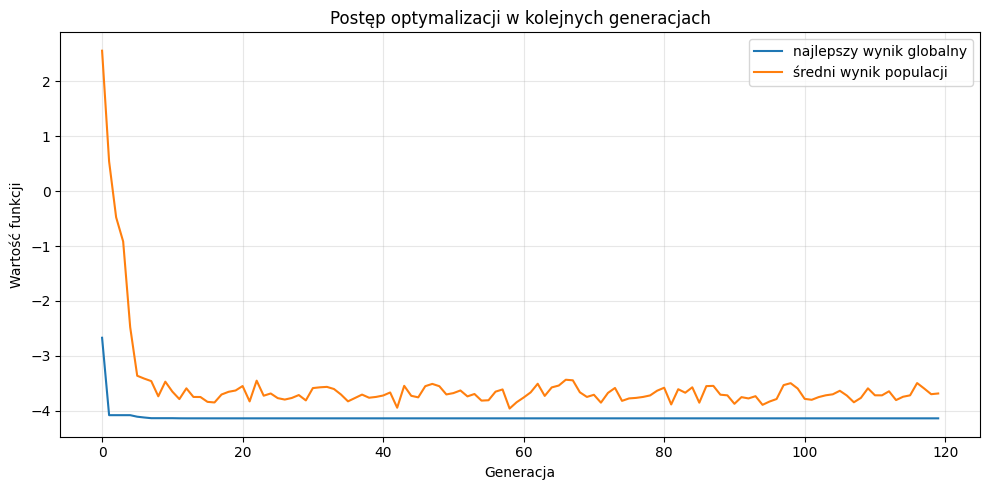

In [12]:
# -----------------------------
# URUCHOMIENIE
# -----------------------------
if __name__ == '__main__':
    best_solution, best_score, best_history, mean_history, best_points = genetic_algorithm()

    print('Najlepsze znalezione rozwiązanie:')
    print(f'x = {best_solution[0]:.6f}')
    print(f'y = {best_solution[1]:.6f}')
    print(f'wartość funkcji = {best_score:.6f}')

    plot_results(best_solution, best_score, best_history, mean_history, best_points)